## Problem 4:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

In [7]:
retail_data = pd.read_csv('RSFHFS.csv', header=0, index_col=0, na_values='.')
retail_data.index = pd.to_datetime(retail_data.index)
retail_data = retail_data.ffill()
retail_data.columns = ['sales']

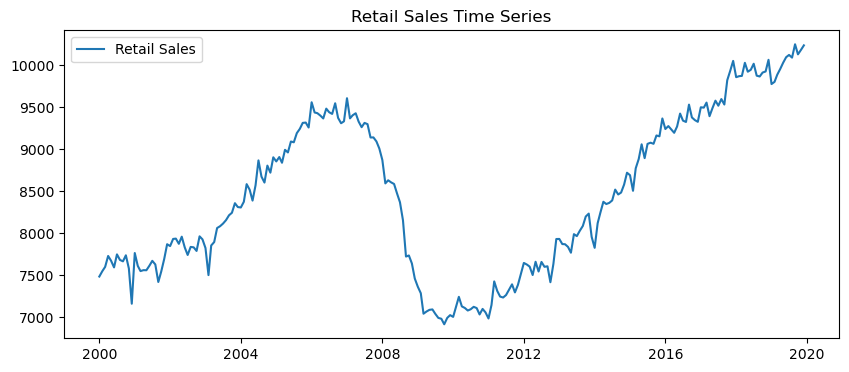

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(retail_data, label='Retail Sales')
plt.title("Retail Sales Time Series")
plt.legend()
plt.show()

In [11]:
train = retail_data[:'2015']
test = retail_data['2016':]

In [13]:
import itertools
p_values = range(3)
d_values = range(3)
q_values = range(3)
best_aic = np.inf
best_order = None
best_model = None

In [15]:
for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=order, freq='MS')
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = order
            best_model = model.fit()
    except Exception as e:
        print(f"Error with order {order}: {e}")
        continue

print(f"Best ARIMA model order: {best_order}")


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be use

Best ARIMA model order: (2, 2, 2)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [17]:
res = best_model

In [19]:
forecast = res.get_forecast(steps=len(test))
fc = forecast.summary_frame()

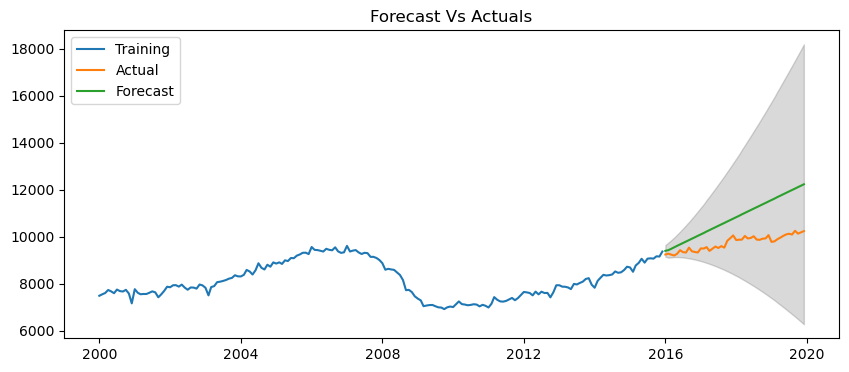

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(train, label='Training')
plt.plot(test, label='Actual')
plt.plot(fc['mean'], label='Forecast')
plt.fill_between(fc.index, fc['mean_ci_lower'], fc['mean_ci_upper'], color='k', alpha=0.15)
plt.title('Forecast Vs Actuals')
plt.legend()
plt.show()

In [23]:
def forecast_accuracy(forecast, actual):
    mae = np.mean(np.abs(forecast - actual))
    rmse = np.sqrt(np.mean((forecast - actual) ** 2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return { 'MAE': mae, 'RMSE': rmse, 'MAPE': mape }

accuracy = forecast_accuracy(fc['mean'], test['sales'])
print(accuracy)

{'MAE': 1068.0147650813205, 'RMSE': 1207.6595846724958, 'MAPE': 10.826841458169206}


## Problem 5:

In [25]:
djia_data = pd.read_csv('DJIA.csv', header=0, index_col=0, na_values='.')
djia_data.index = pd.to_datetime(djia_data.index)
djia_data = djia_data.ffill()
djia_data.columns = ['price']

In [27]:
djia_data['return'] = djia_data['price'].pct_change() * 100
djia_data['sqret'] = djia_data['return']**2

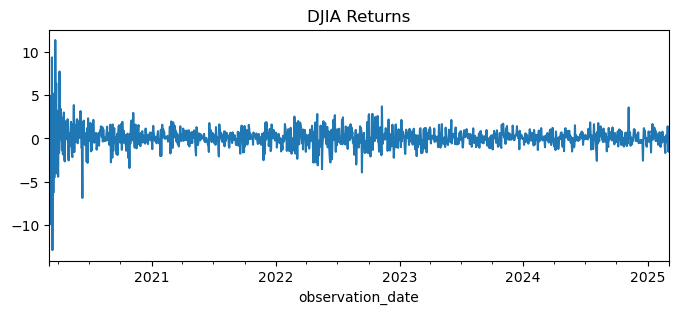

In [29]:
djia_data['return'].plot(figsize=(8,3), title='DJIA Returns')
plt.show()

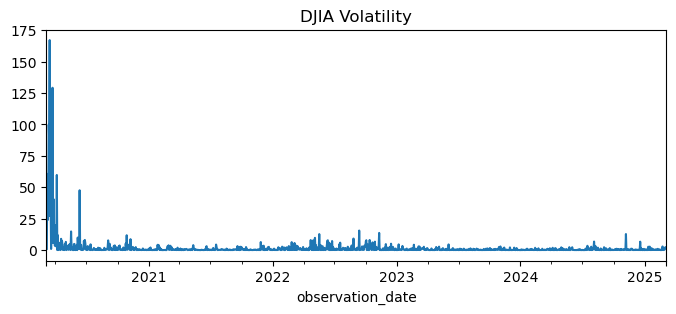

In [31]:
djia_data['sqret'].plot(figsize=(8,3), title='DJIA Volatility')
plt.show()

In [33]:
model_arch = arch_model(djia_data['return'].dropna(), mean='Constant', vol='ARCH', p=2)
res_arch = model_arch.fit(update_freq=2)
print(res_arch.summary())

Iteration:      2,   Func. Count:     14,   Neg. LLF: 679701744.5731144
Iteration:      4,   Func. Count:     26,   Neg. LLF: 1889.385440408121
Iteration:      6,   Func. Count:     40,   Neg. LLF: 1806.375271866303
Iteration:      8,   Func. Count:     50,   Neg. LLF: 1806.3299241708053
Iteration:     10,   Func. Count:     59,   Neg. LLF: 1806.3298962597482
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1806.329896259716
            Iterations: 10
            Function evaluations: 59
            Gradient evaluations: 10
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1806.33
Distribution:                  Normal   AIC:                           3620.66
Method:            Maximum Likelih

In [35]:
model_garch = arch_model(djia_data['return'].dropna(), mean='Constant', vol='GARCH', p=1, q=1)
res_garch = model_garch.fit(update_freq=2)
print(res_garch.summary())

Iteration:      2,   Func. Count:     14,   Neg. LLF: 4983637725.7776375
Iteration:      4,   Func. Count:     29,   Neg. LLF: 2184.6899373477136
Iteration:      6,   Func. Count:     42,   Neg. LLF: 1731.0430238091963
Iteration:      8,   Func. Count:     52,   Neg. LLF: 1731.042776076528
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1731.042776076528
            Iterations: 8
            Function evaluations: 52
            Gradient evaluations: 8
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1731.04
Distribution:                  Normal   AIC:                           3470.09
Method:            Maximum Likelihood   BIC:                           3490.78
                            